## Section 2.4: Maximum Likelihood Estimation
**Topics:** MLE for Random Samples and Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1euNvYBayaD8QP92XkZZ0J3sxV0V6m6i1?usp=sharing)

In [1]:
# Import Necessary Packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Formatting and Spacing:
np.set_printoptions(formatter={'int': str})

## Section 2.4.1: MLE for Random Samples

Maximum Likelihood Estimation (MLE) uses parameters (mean, standard deviation, etc) from random sample measurements to determine the probability density function (pdf). For instance, we may define MLE of the mean and standard deviation (μ = X and σ = (Xᵢ - X)^2 / n), where X is a random sample and n is the number of samples in the random sample.

In this example, we show how MLE may be used from a random sample to understand the probability distribution function using Bernoulli's Distribution.


Number of successes from the sample: 50
MLE p-hat 0.684931506849315


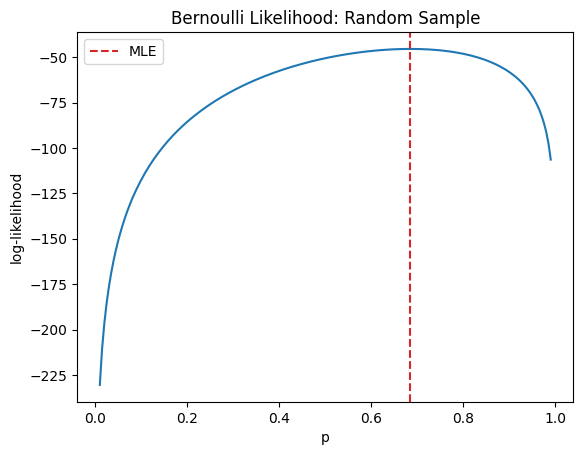

In [13]:
# Define a random natural number of samples from 10 to 100.
n = np.random.randint(10, 100)
# Define a random true probability from 0.25 to 0.75
# Then, calculate the sample and MLE p_hat using random binomial and sample.mean()
t_prob = np.random.uniform(0.25, 0.75)
sample = np.random.binomial(1, t_prob, n)
p_hat = sample.mean()
# Start creating the grid to show the PDF.
# Show probabilties between 0.01 to 0.99 to show probability range and p_hat
grid = np.linspace(0.01, 0.99, 200)
log_likelihood = sample.sum() * np.log(grid) + (n - sample.sum()) * np.log(1 - grid)
# Print out p_hat and number of sample successes.
print("Number of successes from the sample:", sample.sum())
print("MLE p-hat", p_hat)
# Show log-likelihood graph:
plt.plot(grid, log_likelihood)
plt.axvline(p_hat, color="tab:red", linestyle="--", label="MLE")
plt.xlabel("p")
plt.ylabel("log-likelihood")
plt.title("Bernoulli Likelihood: Random Sample")
plt.legend()
plt.show()

## 2.4.2 Linear Regression

Linear regression uses random variables to measure relationships between a dependent and an independent variable using residual sum of squares (RSS) to find the best fit for a regression graph. We demonstrate this with an example using two variables to show the best-fit line and RSS.

Estimated Intercept & Slope = [9.66874124 1.29959293]
Residual sum of squares (RSS) = 135405.5394112704
Total sum of squares (TSS) = 151104.54659917956
R-squared = 0.10389500211103775


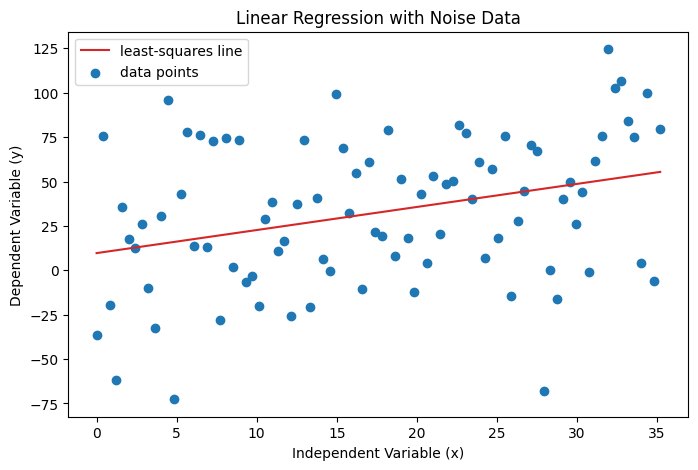

In [33]:
# Generate a random value for noise and x-values:
random_value = np.random.randint(10, 100)
x = np.linspace(0, 0.4 * random_value, random_value)
# Random noise of the same length (random_value,)
noise = np.random.normal(0, 0.4 * random_value, size=random_value)
y = 4.8 + 1.3 * x + noise
# Big X Value
X = np.column_stack([np.ones_like(x),x])
# Fixed the typo from np.lingalg to np.linalg.inv to correctly perform matrix inversion
beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)
y_hat = X @ beta_hat
residuals = y - y_hat

# Print Necessary Regressional Values
print("Estimated Intercept & Slope =", beta_hat)
print("Residual sum of squares (RSS) =", np.sum(residuals**2))
print("Total sum of squares (TSS) =", np.sum((y - np.mean(y))**2))
print("R-squared =", 1 - (np.sum(residuals**2) / np.sum((y - np.mean(y))**2)))

# Plot the linear regression data
plt.figure(figsize=(8, 5))
plt.plot(x, y_hat, color="tab:red", label="least-squares line")
plt.scatter(x, y, color="tab:blue", label="data points")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Dependent Variable (y)")
plt.title("Linear Regression with Noise Data")
plt.legend()
plt.show()

Notice a few things.
For the blue line, its absolute value of the correlation value close to 1 signaling a dependent relationship. For the orange line, an absolute value of the correlation value close to 0 signals high confidence in an independent relationship.

## 2.3.3: Random samples

Random samples are randomly selected subsets of the population where each member has a known chance of being selected to participate. Some subcategories of samples like these include a simple random sample, where each member is equally likely to be selected.

In this example, we use around 128K number of simulations with a randomized sample to measure the sample mean and standard deviation. Then, we graphically represent what the sampling distribution may look like for the sample mean.

SAMPLE MEAN ANALYSIS
Expected value E(X) of sample means = 2.0000126077400906
Variance V(X) of sample means = 0.13388911843058984
Stdev of sample means = 0.36590862032834076
Total number of samples = 128000


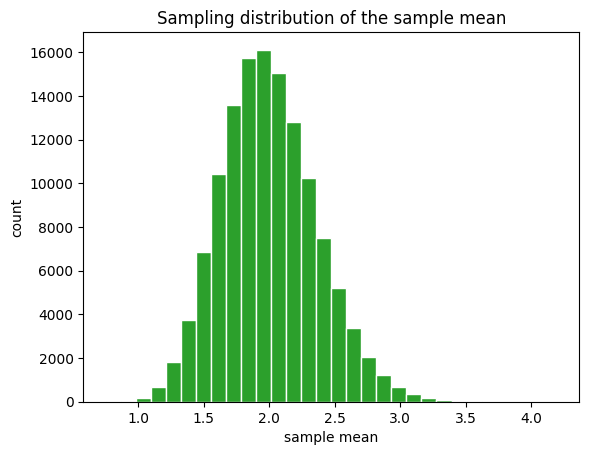

In [ ]:
sample_means = []
rng = np.random.default_rng()
num_simulations = 128000
for _ in range(num_simulations):
    sample = rng.exponential(scale=2.0, size=30)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
print("SAMPLE MEAN ANALYSIS")
print("Expected value E(X) of sample means =", sample_means.mean())
print("Variance V(X) of sample means =", sample_means.var())
print("Stdev of sample means =", sample_means.std())
print("Total number of samples =", len(sample_means))


plt.hist(sample_means, bins=30, color="tab:green", edgecolor="white")
plt.title("Sampling distribution of the sample mean")
plt.xlabel("sample mean")
plt.ylabel("count")
plt.show()